# Etapa 3 — Regressao OLS

Estimacao do modelo de minimos quadrados ordinarios (MQO) para analisar
os determinantes do crescimento do PIB municipal em Mato Grosso do Sul
(2019-2023). Replicamos o modelo de Faganello & Souza (2024) adaptado
ao estado de MS.

**Variavel dependente (Y):** `crescimento_pib`  
**Variaveis explicativas (X1-X9):** log PIB per capita, investimento/PIB,
gasto pessoal/PIB, receita corrente/PIB, crescimento populacional,
area/habitante, distancia da capital, dummy pequeno municipio,
interacao dummy*pessoal.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import het_white, linear_reset
import scipy.stats as stats
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Carga e preparacao dos dados

In [2]:
def localizar_outputs() -> Path:
    cwd = Path.cwd().resolve()
    candidatos = [cwd, cwd.parent, cwd / 'Etapa3' / 'Material_entrega', cwd.parent.parent]
    for c in candidatos:
        p = c / 'outputs' / 'base_etapa3_ms.csv'
        if p.exists():
            return c / 'outputs'
    raise FileNotFoundError('Nao encontrei outputs/base_etapa3_ms.csv')

OUTPUTS = localizar_outputs()
base = pd.read_csv(OUTPUTS / 'base_etapa3_ms.csv', sep=';', decimal=',')

VARIAVEL_Y = 'crescimento_pib'
VARIAVEIS_X = [
    'log_pib_per_capita',
    'investimento_pib',
    'gasto_pessoal_pib',
    'receita_corrente_pib',
    'crescimento_populacao',
    'area_por_habitante',
    'distancia_capital_km',
    'dummy_pequeno_municipio',
    'interacao_pequeno_pessoal',
]
ROTULOS_X = {
    'log_pib_per_capita':        'X1 — log PIB per capita',
    'investimento_pib':          'X2 — Investimento / PIB',
    'gasto_pessoal_pib':         'X3 — Gasto Pessoal / PIB',
    'receita_corrente_pib':      'X4 — Receita Corrente / PIB',
    'crescimento_populacao':     'X5 — Crescimento Populacional',
    'area_por_habitante':        'X6 — Area por Habitante',
    'distancia_capital_km':      'X7 — Distancia da Capital (km)',
    'dummy_pequeno_municipio':   'X8 — Dummy Pequeno Municipio',
    'interacao_pequeno_pessoal': 'X9 — Interacao (Dummy x Pessoal)',
}

# Amostra de regressao: remover NaN nas variaveis do modelo
df_reg = base[[VARIAVEL_Y] + VARIAVEIS_X].dropna().copy()
print(f'Observacoes totais na base : {len(base)}')
print(f'Observacoes na regressao   : {len(df_reg)}')
print(f'Removidas por NaN          : {len(base) - len(df_reg)}')
print(f'Municipios cobertos        : {base.loc[df_reg.index, "cod_ibge"].nunique() if "cod_ibge" in base.columns else "n/d"}')
df_reg.describe().T

Observacoes totais na base : 395
Observacoes na regressao   : 395
Removidas por NaN          : 0
Municipios cobertos        : 79


,count,mean,std,min,25%,50%,75%,max
crescimento_pib,395.0000,0.1545,0.1951,-0.5817,0.0308,0.1418,0.2667,1.0947
log_pib_per_capita,395.0000,10.7860,0.5946,9.3778,10.3845,10.7284,11.1408,12.9253
investimento_pib,395.0000,0.0139,0.0114,0.0009,0.0060,0.0109,0.0172,0.0726
gasto_pessoal_pib,395.0000,0.0659,0.0291,0.0144,0.0430,0.0615,0.0836,0.1664
receita_corrente_pib,395.0000,0.1422,0.0658,0.0326,0.0924,0.1289,0.1735,0.3604
crescimento_populacao,395.0000,0.0077,0.0773,-0.2799,-0.0024,0.0081,0.0178,0.3887
area_por_habitante,395.0000,0.2621,0.2713,0.0088,0.0863,0.1612,0.3801,1.5995
distancia_capital_km,395.0000,277.6889,117.2589,0.0000,198.0000,289.2400,368.5400,469.4100
dummy_pequeno_municipio,395.0000,0.2532,0.4354,0.0000,0.0000,0.0000,1.0000,1.0000
interacao_pequeno_pessoal,395.0000,0.0177,0.0343,0.0000,0.0000,0.0000,0.0145,0.1362


## 2. Amostra de regressao

A regressao usa dados empilhados (`pooled OLS`) para os 5 exercicios fiscais
(2019-2023). Cada linha e um municipio-ano. Nao aplicamos efeitos fixos
nesta etapa; um modelo com efeitos fixos de municipio (within estimator)
seria o proximo passo natural.

In [3]:
# Distribuicao da amostra por ano
obs_ano = base.dropna(subset=[VARIAVEL_Y] + VARIAVEIS_X).groupby('ano').size().reset_index(name='obs')
print('Observacoes por ano:')
print(obs_ano.to_string(index=False))

Observacoes por ano:
 ano  obs
2019   79
2020   79
2021   79
2022   79
2023   79


## 3. Regressao OLS — modelo completo (dados empilhados 2019–2023)

Estimamos por MQO o modelo:

$$Y_i = \beta_0 + \beta_1 X1 + \beta_2 X2 + \beta_3 X3 + \beta_4 X4 + \beta_5 X5 + \beta_6 X6 + \beta_7 X7 + \beta_8 X8 + \beta_9 X9 + \varepsilon_i$$

Os erros-padrao sao classicos (nao-robustos). Use `cov_type='HC3'` no `.fit()` para erros robustos a heterocedasticidade apos o teste de White.

In [4]:
formula = (
    'crescimento_pib ~ '
    'log_pib_per_capita + investimento_pib + gasto_pessoal_pib + '
    'receita_corrente_pib + crescimento_populacao + area_por_habitante + '
    'distancia_capital_km + dummy_pequeno_municipio + interacao_pequeno_pessoal'
)

modelo = smf.ols(formula=formula, data=df_reg).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        crescimento_pib   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     3.783
Date:                Mon, 18 May 2026   Prob (F-statistic):           0.000138
Time:                        16:23:23   Log-Likelihood:                 102.22
No. Observations:                 395   AIC:                            -184.4
Df Residuals:                     385   BIC:                            -144.7
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [5]:
# Tabela de resultados formatada
coef_df = pd.DataFrame({
    'Variavel': ['Intercepto'] + [ROTULOS_X.get(v, v) for v in VARIAVEIS_X],
    'Coeficiente': modelo.params.values,
    'Erro Padrao': modelo.bse.values,
    'Estatistica t': modelo.tvalues.values,
    'p-valor': modelo.pvalues.values,
    'IC 2.5%': modelo.conf_int()[0].values,
    'IC 97.5%': modelo.conf_int()[1].values,
})
coef_df['Signif.'] = coef_df['p-valor'].apply(
    lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else ''))
)

print(f'R2          : {modelo.rsquared:.4f}')
print(f'R2 ajustado : {modelo.rsquared_adj:.4f}')
print(f'F-estatistica: {modelo.fvalue:.4f}  (p={modelo.f_pvalue:.4f})')
print(f'AIC         : {modelo.aic:.2f}')
print(f'BIC         : {modelo.bic:.2f}')
print(f'Observacoes : {int(modelo.nobs)}')
print()
coef_df

R2          : 0.0812
R2 ajustado : 0.0598
F-estatistica: 3.7826  (p=0.0001)
AIC         : -184.45
BIC         : -144.66
Observacoes : 395



,Variavel,Coeficiente,Erro Padrao,Estatistica t,p-valor,IC 2.5%,IC 97.5%,Signif.
0,Intercepto,-0.4383,0.3549,-1.2351,0.2175,-1.1360,0.2594,
1,X1 — log PIB per capita,0.0553,0.0305,1.8109,0.0709,-0.0047,0.1153,*
2,X2 — Investimento / PIB,1.5904,1.1072,1.4364,0.1517,-0.5866,3.7673,
3,X3 — Gasto Pessoal / PIB,-1.5677,1.2483,-1.2559,0.2099,-4.0219,0.8866,
4,X4 — Receita Corrente / PIB,0.6470,0.5791,1.1173,0.2646,-0.4916,1.7856,
5,X5 — Crescimento Populacional,0.3452,0.1241,2.7826,0.0057,0.1013,0.5892,***
6,X6 — Area por Habitante,-0.0163,0.0460,-0.3549,0.7229,-0.1069,0.0742,
7,X7 — Distancia da Capital (km),-0.0000,0.0001,-0.3744,0.7083,-0.0002,0.0001,
8,X8 — Dummy Pequeno Municipio,0.0811,0.0576,1.4081,0.1599,-0.0321,0.1943,
9,X9 — Interacao (Dummy x Pessoal),-1.3607,0.7767,-1.7519,0.0806,-2.8878,0.1664,*


## 4. Diagnostico de multicolinearidade — VIF

O Fator de Inflacao da Variancia (VIF) mede o quanto a variancia de cada
coeficiente aumenta por conta da correlacao com os demais regressores.
Regra pratica: VIF < 5 indica multicolinearidade aceitavel; VIF > 10 e critico.

In [6]:
X_vif = sm.add_constant(df_reg[VARIAVEIS_X])
vif_df = pd.DataFrame({
    'Variavel': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_df['Interpretacao'] = vif_df['VIF'].apply(
    lambda v: 'OK (< 5)' if v < 5 else ('Moderado (5-10)' if v < 10 else 'ALTO (> 10)')
)
vif_df.sort_values('VIF', ascending=False)

,Variavel,VIF,Interpretacao
0,const,1389.5429,ALTO (> 10)
4,receita_corrente_pib,15.9710,ALTO (> 10)
3,gasto_pessoal_pib,14.4993,ALTO (> 10)
9,interacao_pequeno_pessoal,7.7995,Moderado (5-10)
8,dummy_pequeno_municipio,6.9155,Moderado (5-10)
1,log_pib_per_capita,3.6245,OK (< 5)
2,investimento_pib,1.7630,OK (< 5)
6,area_por_habitante,1.7173,OK (< 5)
7,distancia_capital_km,1.1372,OK (< 5)
5,crescimento_populacao,1.0119,OK (< 5)


## 5. Normalidade dos residuos — Jarque-Bera

H0: Os residuos seguem distribuicao normal (assimetria=0, curtose=3).  
Rejeitar H0 indica que os residuos nao sao normais, o que afeta a validade
dos testes t e F em amostras pequenas (n > 200 o TCL mitiga o problema).

Jarque-Bera: estatistica=114.6154  p-valor=0.0000
Assimetria  : 0.4611
Curtose     : 5.4726
Conclusao   : H0 REJEITADA (residuos nao normais) ao nivel 5%


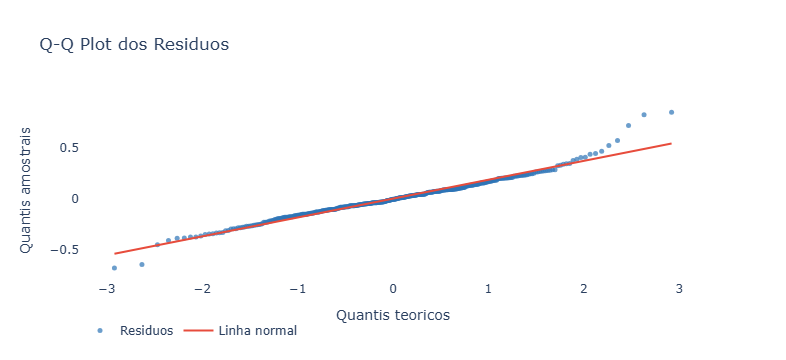

In [7]:
jb_stat, jb_pval, jb_skew, jb_kurt = jarque_bera(modelo.resid)
print(f'Jarque-Bera: estatistica={jb_stat:.4f}  p-valor={jb_pval:.4f}')
print(f'Assimetria  : {jb_skew:.4f}')
print(f'Curtose     : {jb_kurt:.4f}')
print(f'Conclusao   : {"H0 nao rejeitada (residuos normais)" if jb_pval > 0.05 else "H0 REJEITADA (residuos nao normais)"} ao nivel 5%')

# Q-Q plot
(osm, osr), (slope, intercept, r) = stats.probplot(modelo.resid)
fig_qq = go.Figure()
fig_qq.add_scatter(x=osm, y=osr, mode='markers', name='Residuos',
                   marker=dict(color='#2E75B6', size=5, opacity=0.7))
fig_qq.add_scatter(x=[osm[0], osm[-1]],
                   y=[slope*osm[0]+intercept, slope*osm[-1]+intercept],
                   mode='lines', name='Linha normal',
                   line=dict(color='#E74C3C', width=2))
fig_qq.update_layout(title='Q-Q Plot dos Residuos', plot_bgcolor='white',
                     xaxis_title='Quantis teoricos', yaxis_title='Quantis amostrais',
                     legend=dict(orientation='h', y=-0.2))
fig_qq.show()

## 6. Heterocedasticidade — Teste de White

H0: Os erros sao homocedastticos (variancia constante).  
Rejeitar H0 indica heterocedasticidade: os coeficientes ainda sao
nao-viesados, mas os erros-padrao classicos sao incorretos. Solucao:
usar erros robustos (HC3) na estimacao.

In [8]:
white_stat, white_pval, white_f, white_f_pval = het_white(modelo.resid, modelo.model.exog)
print(f'Teste de White:')
print(f'  Estatistica LM  : {white_stat:.4f}')
print(f'  p-valor (LM)    : {white_pval:.4f}')
print(f'  Estatistica F   : {white_f:.4f}')
print(f'  p-valor (F)     : {white_f_pval:.4f}')
print(f'  Conclusao       : {"H0 nao rejeitada (homocedasticidade)" if white_pval > 0.05 else "H0 REJEITADA (heterocedasticidade detectada)"} ao nivel 5%')

# Se heterocedasticidade presente, reestima com erros robustos
if white_pval <= 0.05:
    modelo_hc3 = smf.ols(formula=formula, data=df_reg).fit(cov_type='HC3')
    print()
    print('--- Reestimacao com erros robustos HC3 ---')
    print(modelo_hc3.summary())

Teste de White:
  Estatistica LM  : 102.6944
  p-valor (LM)    : 0.0000
  Estatistica F   : 2.4171
  p-valor (F)     : 0.0000
  Conclusao       : H0 REJEITADA (heterocedasticidade detectada) ao nivel 5%

--- Reestimacao com erros robustos HC3 ---
                            OLS Regression Results                            
Dep. Variable:        crescimento_pib   R-squared:                       0.081
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     2.937
Date:                Mon, 18 May 2026   Prob (F-statistic):            0.00221
Time:                        16:23:35   Log-Likelihood:                 102.22
No. Observations:                 395   AIC:                            -184.4
Df Residuals:                     385   BIC:                            -144.7
Df Model:                           9                                         
Covariance Type:                  HC3     

## 7. Autocorrelacao dos residuos — Durbin-Watson

H0: Nao ha autocorrelacao serial dos residuos (DW proximo de 2).  
DW < 1.5 indica autocorrelacao positiva; DW > 2.5 indica negativa.
Em dados de corte transversal anuais (pooled), este teste e menos critico
do que em series temporais.

In [9]:
dw_stat = durbin_watson(modelo.resid)
print(f'Durbin-Watson: {dw_stat:.4f}')
if dw_stat < 1.5:
    print('  -> Possivel autocorrelacao positiva')
elif dw_stat > 2.5:
    print('  -> Possivel autocorrelacao negativa')
else:
    print('  -> Sem evidencia de autocorrelacao serial')

Durbin-Watson: 1.7846
  -> Sem evidencia de autocorrelacao serial


## 8. Especificacao do modelo — Ramsey RESET

H0: O modelo esta corretamente especificado (sem variaveis omitidas ou
forma funcional incorreta). Rejeitar H0 sugere que o modelo pode precisar
de termos quadraticos, cubicos ou outras variaveis.

In [10]:
reset_result = linear_reset(modelo, power=3, use_f=True)
print(f'Ramsey RESET (potencias 2 e 3):')
print(f'  Estatistica F: {reset_result.statistic:.4f}')
print(f'  p-valor      : {reset_result.pvalue:.4f}')
print(f'  Conclusao    : {"H0 nao rejeitada (especificacao adequada)" if reset_result.pvalue > 0.05 else "H0 REJEITADA (possivel misspecification)"} ao nivel 5%')

Ramsey RESET (potencias 2 e 3):
  Estatistica F: 0.8778
  p-valor      : 0.4165
  Conclusao    : H0 nao rejeitada (especificacao adequada) ao nivel 5%


## 9. Teste de Wald — hipotese dos pequenos municipios

Testamos a hipotese conjunta de que X8 (`dummy_pequeno_municipio`) e
X9 (`interacao_pequeno_pessoal`) sao **simultaneamente iguais a zero**,
ou seja, de que o porte do municipio nao afeta o crescimento do PIB.

H0: beta_8 = 0 e beta_9 = 0

In [11]:
wald = modelo.wald_test("dummy_pequeno_municipio = 0, interacao_pequeno_pessoal = 0")
wald_stat = float(np.squeeze(wald.statistic))
wald_pval = float(np.squeeze(wald.pvalue))
print(f"Teste de Wald (X8 = X9 = 0):")
print(f"  Estatistica F: {wald_stat:.4f}")
print(f"  p-valor      : {wald_pval:.4f}")
conclusao_wald = "H0 nao rejeitada (X8 e X9 nao significativos conjuntamente)" if wald_pval > 0.05 else "H0 REJEITADA (efeito de porte identificado conjuntamente)"
print(f"  Conclusao    : {conclusao_wald} ao nivel 5%")

C:\Users\marco\miniconda3\envs\work\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


Teste de Wald (X8 = X9 = 0):
  Estatistica F: 1.5623
  p-valor      : 0.2110
  Conclusao    : H0 nao rejeitada (X8 e X9 nao significativos conjuntamente) ao nivel 5%


## 10. Tabela resumo dos testes diagnosticos

In [12]:
resumo_diag = pd.DataFrame([
    {"Teste": "Jarque-Bera (normalidade)",   "Estatistica": round(jb_stat, 4),                        "p-valor": round(jb_pval, 4),    "H0": "Residuos normais",             "Resultado": "Nao rejeitada" if jb_pval > 0.05 else "REJEITADA"},
    {"Teste": "White (heterocedasticidade)", "Estatistica": round(white_stat, 4),                      "p-valor": round(white_pval, 4), "H0": "Homocedasticidade",            "Resultado": "Nao rejeitada" if white_pval > 0.05 else "REJEITADA"},
    {"Teste": "Durbin-Watson (autocorr.)",   "Estatistica": round(dw_stat, 4),                         "p-valor": None,                 "H0": "Sem autocorrelacao (DW~2)",    "Resultado": "OK" if 1.5 <= dw_stat <= 2.5 else "Atencao"},
    {"Teste": "Ramsey RESET (especif.)",     "Estatistica": round(float(reset_result.statistic), 4),   "p-valor": round(reset_result.pvalue, 4), "H0": "Modelo bem especificado", "Resultado": "Nao rejeitada" if reset_result.pvalue > 0.05 else "REJEITADA"},
    {"Teste": "Wald (X8=X9=0)",             "Estatistica": round(wald_stat, 4),                       "p-valor": round(wald_pval, 4),  "H0": "Porte nao afeta crescimento", "Resultado": "Nao rejeitada" if wald_pval > 0.05 else "REJEITADA"},
])
resumo_diag

,Teste,Estatistica,p-valor,H0,Resultado
0,Jarque-Bera (normalidade),114.6154,0.0000,Residuos normais,REJEITADA
1,White (heterocedasticidade),102.6944,0.0000,Homocedasticidade,REJEITADA
2,Durbin-Watson (autocorr.),1.7846,NaN,Sem autocorrelacao (DW~2),OK
3,Ramsey RESET (especif.),0.8778,0.4165,Modelo bem especificado,Nao rejeitada
4,Wald (X8=X9=0),1.5623,0.2110,Porte nao afeta crescimento,Nao rejeitada


## 11. Diagnostico visual dos residuos

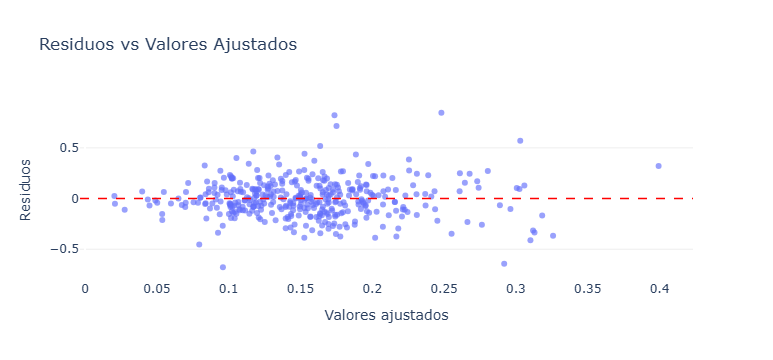

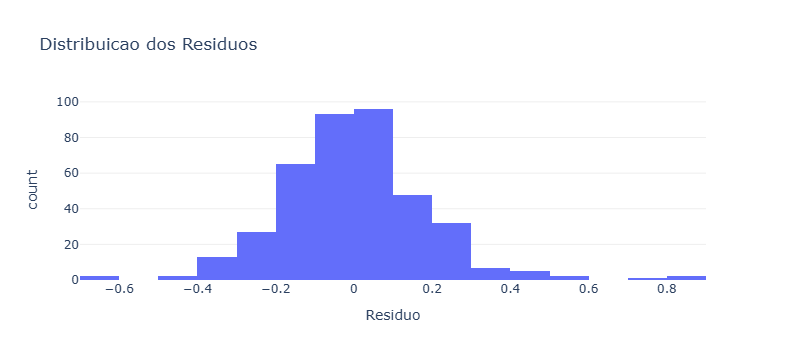

In [13]:
fitted = modelo.fittedvalues
resid  = modelo.resid

# Residuos vs Valores ajustados
fig_rv = px.scatter(
    x=fitted, y=resid,
    labels={'x': 'Valores ajustados', 'y': 'Residuos'},
    title='Residuos vs Valores Ajustados',
    opacity=0.65,
)
fig_rv.add_hline(y=0, line_dash='dash', line_color='red', line_width=1.5)
fig_rv.update_layout(plot_bgcolor='white', yaxis=dict(gridcolor='#eeeeee'))
fig_rv.show()

# Histograma dos residuos
fig_rh = px.histogram(x=resid, nbins=25, title='Distribuicao dos Residuos',
                      labels={'x': 'Residuo', 'y': 'Frequencia'})
fig_rh.update_layout(plot_bgcolor='white', yaxis=dict(gridcolor='#eeeeee'))
fig_rh.show()

## 12. Regressoes por ano (2019–2023)

Estimamos o mesmo modelo para cada exercicio fiscal separadamente
(79 observacoes por ano, 9 regressores). Os resultados servem para
avaliar a estabilidade dos coeficientes ao longo do tempo.

In [14]:
resultados_ano = []
for ano in sorted(df_reg.index.map(lambda i: base.loc[i, 'ano'] if i in base.index else None).dropna().unique() if 'ano' in base.columns else []):
    pass  # substituido abaixo

# Merge do ano de volta
df_reg2 = df_reg.copy()
df_reg2['ano'] = base.loc[df_reg2.index, 'ano'].values

resultados_ano = []
for ano in sorted(df_reg2['ano'].unique()):
    df_ano = df_reg2[df_reg2['ano'] == ano]
    if len(df_ano) < len(VARIAVEIS_X) + 2:
        continue
    m = smf.ols(formula=formula, data=df_ano).fit()
    row = {'Ano': int(ano), 'N': int(m.nobs), 'R2': round(m.rsquared, 4),
           'R2_adj': round(m.rsquared_adj, 4), 'F': round(m.fvalue, 4),
           'p_F': round(m.f_pvalue, 4), 'AIC': round(m.aic, 2)}
    for v in VARIAVEIS_X:
        row[v] = round(m.params.get(v, float('nan')), 4)
    resultados_ano.append(row)

res_ano_df = pd.DataFrame(resultados_ano)
res_ano_df

,Ano,N,R2,R2_adj,F,p_F,AIC,log_pib_per_capita,investimento_pib,gasto_pessoal_pib,receita_corrente_pib,crescimento_populacao,area_por_habitante,distancia_capital_km,dummy_pequeno_municipio,interacao_pequeno_pessoal
0,2019,79,0.1363,0.0236,1.2097,0.3034,-104.8900,-0.0338,-2.8613,-3.0655,1.2180,-2.5669,0.1090,0.0001,-0.0969,0.4169
1,2020,79,0.1357,0.0229,1.2034,0.3073,-52.2600,-0.0090,-1.0876,-4.2372,1.2808,0.9313,-0.0980,0.0001,0.0792,-0.1287
2,2021,79,0.1347,0.0219,1.1939,0.3130,-66.9300,-0.1054,-1.1682,2.7644,-2.5012,2.3012,0.1175,0.0003,0.0902,0.3125
3,2022,79,0.3045,0.2138,3.3564,0.0018,-21.2300,0.0743,2.9952,-2.5316,1.0985,0.3945,0.0650,-0.0007,0.1919,-4.5186
4,2023,79,0.1761,0.0687,1.6390,0.1214,-17.9000,-0.0209,5.1600,-2.9724,0.7652,0.2497,-0.0732,0.0004,0.2080,-1.3946


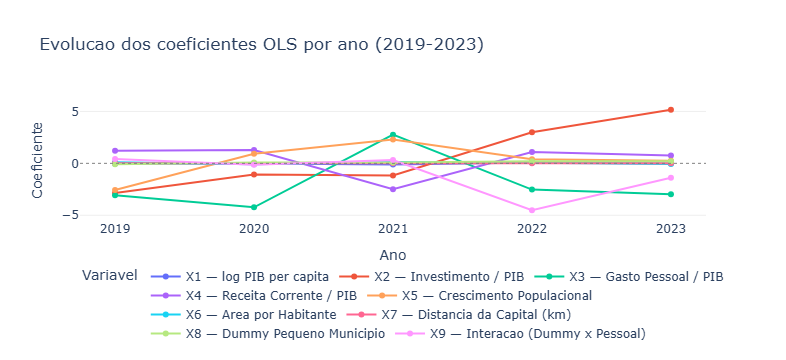

In [15]:
# Grafico: evolucao dos coeficientes por ano
coef_long = res_ano_df[['Ano'] + VARIAVEIS_X].melt(id_vars='Ano', var_name='variavel', value_name='coef')
coef_long['variavel'] = coef_long['variavel'].map(ROTULOS_X)

fig_coef = px.line(
    coef_long, x='Ano', y='coef', color='variavel', markers=True,
    title='Evolucao dos coeficientes OLS por ano (2019-2023)',
    labels={'coef': 'Coeficiente', 'variavel': 'Variavel'},
)
fig_coef.add_hline(y=0, line_dash='dot', line_color='gray', line_width=1)
fig_coef.update_xaxes(tickmode='linear', dtick=1)
fig_coef.update_layout(plot_bgcolor='white', yaxis=dict(gridcolor='#eeeeee'),
                       legend=dict(orientation='h', y=-0.35, x=0))
fig_coef.show()

## 13. Selecao de modelo

Comparamos tres especificacoes pelo AIC/BIC para identificar o modelo
mais parcimonioso:

- **M1 — Completo**: todos os 9 regressores  
- **M2 — Sem interacao**: X1-X8 (remove X9)  
- **M3 — Sem porte**: X1-X7 (remove X8 e X9)  

In [16]:
especificacoes = {
    'M1 — Completo (X1-X9)': formula,
    'M2 — Sem interacao (X1-X8)': formula.replace(' + interacao_pequeno_pessoal', ''),
    'M3 — Sem porte (X1-X7)': formula.replace(' + dummy_pequeno_municipio + interacao_pequeno_pessoal', ''),
}

sel_rows = []
for nome, f in especificacoes.items():
    m = smf.ols(formula=f, data=df_reg).fit()
    sel_rows.append({
        'Modelo': nome, 'k': int(m.df_model + 1),
        'R2_adj': round(m.rsquared_adj, 4),
        'AIC': round(m.aic, 2), 'BIC': round(m.bic, 2),
        'F': round(m.fvalue, 4), 'p_F': round(m.f_pvalue, 4),
    })

sel_df = pd.DataFrame(sel_rows)
print('Menor AIC e melhor:')
sel_df

Menor AIC e melhor:


,Modelo,k,R2_adj,AIC,BIC,F,p_F
0,M1 — Completo (X1-X9),10,0.0598,-184.4500,-144.6600,3.7826,0.0001
1,M2 — Sem interacao (X1-X8),9,0.0547,-183.3100,-147.5000,3.8511,0.0002
2,M3 — Sem porte (X1-X7),8,0.0570,-185.2500,-153.4200,4.4041,0.0001


## 14. Exportacao dos resultados para Excel

In [17]:
borda = {'left': 'thin', 'right': 'thin', 'top': 'thin', 'bottom': 'thin'}

def estilo_cab(ws, row):
    for cell in ws[row]:
        cell.font   = Font(bold=True, color='FFFFFF', size=10)
        cell.fill   = PatternFill('solid', fgColor='1F3864')
        cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
        cell.border = Border(**{s: Side(style='thin', color='BFBFBF') for s in borda})

def auto_width(ws, min_w=10, max_w=40):
    for col in ws.columns:
        w = max(len(str(c.value or '')) for c in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max(w+2, min_w), max_w)

wb = openpyxl.Workbook()

# --- Aba Coeficientes ---
ws1 = wb.active
ws1.title = 'Coeficientes'
ws1.append(list(coef_df.columns))
estilo_cab(ws1, 1)
for _, row in coef_df.iterrows():
    ws1.append(list(row))
auto_width(ws1)

# --- Aba VIF ---
ws2 = wb.create_sheet('VIF')
ws2.append(list(vif_df.columns))
estilo_cab(ws2, 1)
for _, row in vif_df.iterrows():
    ws2.append(list(row))
auto_width(ws2)

# --- Aba Diagnosticos ---
ws3 = wb.create_sheet('Diagnosticos')
ws3.append(list(resumo_diag.columns))
estilo_cab(ws3, 1)
for _, row in resumo_diag.iterrows():
    ws3.append(list(row))
auto_width(ws3)

# --- Aba Por Ano ---
ws4 = wb.create_sheet('Por Ano')
ws4.append(list(res_ano_df.columns))
estilo_cab(ws4, 1)
for _, row in res_ano_df.iterrows():
    ws4.append(list(row))
auto_width(ws4)

# --- Aba Selecao ---
ws5 = wb.create_sheet('Selecao Modelo')
ws5.append(list(sel_df.columns))
estilo_cab(ws5, 1)
for _, row in sel_df.iterrows():
    ws5.append(list(row))
auto_width(ws5)

xl_path = OUTPUTS / 'regressao_ols_resultados.xlsx'
wb.save(xl_path)
print(f'Excel salvo: {xl_path}')
print(f'  Abas: Coeficientes, VIF, Diagnosticos, Por Ano, Selecao Modelo')

Excel salvo: C:\Users\marco\Documents\PUC-MINAS\4º Semestre\Eixo 4 - Projeto Mini Ministério da Fazenda\Projeto-Mini-Min-Fazenda\Etapa3\Material_entrega\outputs\regressao_ols_resultados.xlsx
  Abas: Coeficientes, VIF, Diagnosticos, Por Ano, Selecao Modelo


In [18]:
print('=== RESUMO DA REGRESSAO ===')
print(f'Equacao: Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9')
print(f'N = {int(modelo.nobs)}  |  R2 = {modelo.rsquared:.4f}  |  R2adj = {modelo.rsquared_adj:.4f}')
print(f'F = {modelo.fvalue:.4f}  |  p(F) = {modelo.f_pvalue:.4f}')
print(f'AIC = {modelo.aic:.2f}  |  BIC = {modelo.bic:.2f}')
print()
print('Coeficientes significativos (p < 0.10):')
sig = coef_df[coef_df['Signif.'] != '']
for _, r in sig.iterrows():
    print(f'  {r["Variavel"]:<40} beta={r["Coeficiente"]:+.4f}  p={r["p-valor"]:.4f}  {r["Signif."]}')

=== RESUMO DA REGRESSAO ===
Equacao: Y ~ X1 + X2 + X3 + X4 + X5 + X6 + X7 + X8 + X9
N = 395  |  R2 = 0.0812  |  R2adj = 0.0598
F = 3.7826  |  p(F) = 0.0001
AIC = -184.45  |  BIC = -144.66

Coeficientes significativos (p < 0.10):
  X1 — log PIB per capita                  beta=+0.0553  p=0.0709  *
  X5 — Crescimento Populacional            beta=+0.3452  p=0.0057  ***
  X9 — Interacao (Dummy x Pessoal)         beta=-1.3607  p=0.0806  *
